In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Samples to plot
plot_samples = ["ERG", "ELF1", "ERG_DBD_ELF1"]

# Footprint and motif binding score directories (see analysis code for calculations)
footprint_dir = "../Experimental_data_analysis/fimo_footprints/hocomoco_default_pthreshold/representative_hoco_motif/raw_signals"
binding_dir = "binding_score_at_motifs"

# Shared filename suffix for ETS family motif binding score files
ets_binding_suffix = "__orig-human__loc-prom__motif-GABPA.H12CORE.0.PSM.A__type-family__fl25__nuc-7-25-50__trim150.csv"

# Filepaths for the samples used in the final plot
footprint_filepaths = {
    sample: f"{footprint_dir}/{sample}_raw_windows.csv"
    for sample in plot_samples
}

binding_filepaths = {
    sample: f"{binding_dir}/{sample}/{sample}{ets_binding_suffix}"
    for sample in plot_samples
}

## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Helper Functions

In [4]:
# Load one sample footprint matrix and its matching binding score table
def load_sample_data(sample_name, footprint_filepath, binding_filepath):
    fp = pd.read_csv(footprint_filepath, index_col=0)
    binding = pd.read_csv(binding_filepath)
    binding["motif_name_in_fpdf"] = (
        binding["sequence_name"].str.cat(binding["start"].astype(int).astype(str), sep="_")
    )
    binding = binding[binding["motif_name_in_fpdf"].isin(fp.index)]
    return fp, binding

## Data Loading

In [5]:
# Load footprint and binding data for the samples used in the final plot
all_fp = {}
all_binding = {}

for sample_name in plot_samples:
    fp, binding = load_sample_data(
        sample_name,
        footprint_filepaths[sample_name],
        binding_filepaths[sample_name],
    )
    all_fp[sample_name] = fp
    all_binding[sample_name] = binding

# Define position columns spanning -100 to +100 around motif
cols = [f"pos_{i}" for i in range(-100, 101)]

## Plotting

41
36
159


/tmp/ipykernel_1515579/3596830378.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


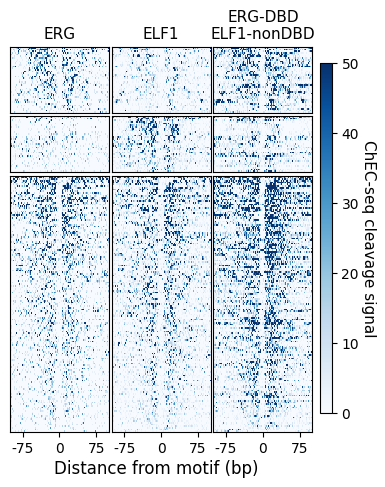

In [6]:
# Plot footprint heatmaps for motif groups based on binding differences between samples
def plot_motif_groups(sample_names, all_fp, all_binding, cols, vmax=80, cmap="Blues",
                      z_hi=3, z_lo=2, z_shared=1, positions=(-75, 0, 75),
                      figsize_per_col=1.3, figsize_base_h=1.0):

    # Require at least two samples for comparison and one additional sample for display
    if len(sample_names) < 3:
        raise ValueError("Provide at least 3 samples: two comparators + at least one extra to display.")

    # First two samples define the grouping logic
    comp1, comp2 = sample_names[:2]

    # Additional samples are included only for visualization
    extra = sample_names[2:]
    plot_samples = [comp1, comp2, *extra]

    # Optional custom names for plot titles
    display_names = {
        "ERG_DBD_ELF1": "ERG-DBD\nELF1-nonDBD",
    }

    # Extract binding data for the two comparator samples
    b1 = all_binding[comp1]
    b2 = all_binding[comp2]

    # Merge binding scores for the same motifs across the two samples
    m = (b1[["motif_name_in_fpdf", "z_score_norm_f7"]]
         .merge(b2[["motif_name_in_fpdf", "z_score_norm_f7"]],
                on="motif_name_in_fpdf", suffixes=("_1", "_2")))

    # Identify motifs strongly bound in comp1 but not in comp2
    g1 = m.query("z_score_norm_f7_1 > @z_hi & z_score_norm_f7_2 < @z_lo")["motif_name_in_fpdf"]
    print(len(g1))

    # Identify motifs strongly bound in comp2 but not in comp1
    g2 = m.query("z_score_norm_f7_2 > @z_hi & z_score_norm_f7_1 < @z_lo")["motif_name_in_fpdf"]
    print(len(g2))

    # Identify motifs bound in both samples (shared binding), excluding previous groups
    mask3 = (
        (m["z_score_norm_f7_1"] > z_shared)
        & (m["z_score_norm_f7_2"] > z_shared)
        & ~m["motif_name_in_fpdf"].isin(pd.concat([g1, g2]))
    )
    g3 = m.loc[mask3, "motif_name_in_fpdf"]
    print(len(g3))

    # Get footprint matrices for the comparator samples
    fp1 = all_fp[comp1]
    fp2 = all_fp[comp2]

    # Compute total signal per motif (sum across positions)
    row_sums1 = fp1[cols].sum(axis=1)
    row_sums2 = fp2[cols].sum(axis=1)

    # Sort motifs in each group by signal strength (descending)
    g1_order = row_sums1.loc[g1].sort_values(ascending=False).index
    g2_order = row_sums2.loc[g2].sort_values(ascending=False).index
    g3_order = (row_sums1 + row_sums2).loc[g3].sort_values(ascending=False).index

    group_idxs = [g1_order, g2_order, g3_order]

    # Extract footprint data for a given group and sample, removing rows with missing values
    def group_mats(idx, sample):
        h = all_fp[sample].loc[idx, cols]
        valid = ~h.isna().any(axis=1)
        return h.loc[valid]

    # Build matrices for each group across all samples to be plotted
    mats = [[group_mats(idx, sample) for sample in plot_samples] for idx in group_idxs]

    # Keep only motifs that exist (without missing values) in all samples
    mats_aligned = []
    for row in mats:
        common = row[0].index
        for h in row[1:]:
            common = common.intersection(h.index)
        mats_aligned.append([h.loc[common] for h in row])

    # Determine subplot height ratios based on number of motifs per group
    height_ratios = [len(row[0]) for row in mats_aligned]

    # Ensure no group is empty after filtering
    if any(r == 0 for r in height_ratios):
        raise ValueError(
            f"At least one group has 0 motifs after filtering/alignment. height_ratios={height_ratios}"
        )

    # Create subplot grid (rows = groups, columns = samples)
    nrows, ncols = 3, len(plot_samples)
    fig_w = max(3.6, figsize_per_col * ncols)
    fig_h = 5

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_w, fig_h),
        sharex=True,
        gridspec_kw={"wspace": 0.03, "hspace": 0.03, "height_ratios": height_ratios}
    )

    # Ensure axes is always 2D (even if only one column)
    if ncols == 1:
        axes = axes.reshape(nrows, 1)

    # Plot heatmaps for each group and sample
    for i in range(nrows):
        for j in range(ncols):
            ax = axes[i, j]
            ax.imshow(
                mats_aligned[i][j],
                aspect="auto",
                cmap=cmap,
                vmax=vmax,
                interpolation="nearest"
            )

            # Set column titles only for the top row
            if i == 0:
                ax.set_title(display_names.get(plot_samples[j], plot_samples[j]), fontsize=11)

            # Remove y-axis ticks for cleaner look
            ax.set_yticks([])

    # Add a shared colorbar on the right
    pos = axes[0, -1].get_position()
    cax = fig.add_axes([pos.x1 + 0.02, pos.y0 - 0.6, 0.03, 0.7])
    cbar = fig.colorbar(axes[0, 0].images[0], cax=cax)
    cbar.set_label("ChEC-seq cleavage signal", fontsize=11, rotation=270, labelpad=12)

    # Show x-axis ticks only on the bottom row
    for ax in axes[:-1, :].ravel():
        ax.tick_params(axis="x", bottom=False, labelbottom=False)

    # Convert position labels into column indices
    positions = list(positions)
    xticks = [cols.index(f"pos_{p}") for p in positions]

    # Apply x-axis ticks to bottom row
    for ax in axes[-1, :]:
        ax.set_xticks(xticks)
        ax.set_xticklabels(positions)

    # Add a shared x-axis label
    fig.supxlabel("Distance from motif (bp)", fontsize=12, y=0.02)

    plt.tight_layout()
    plt.show()


# Run the plot for selected samples
sample_names = ["ERG", "ELF1", "ERG_DBD_ELF1"]
plot_motif_groups(sample_names, all_fp, all_binding, cols, vmax=50)